### LDA_Topic Analysis
#### Load a tabular file aggregated from a specified website or local source and perform LDA Analysis.


===== 語 × トピックの確率行列 =====
      Topic1  Topic2  Topic3
人      0.080   0.047   0.230
友達     0.001   0.001   0.307
車      0.404   0.001   0.001
自分     0.100   0.036   0.110
事故     0.136   0.001   0.001
人間     0.080   0.030   0.018
食      0.001   0.133   0.001
文化     0.001   0.093   0.001
寿司     0.001   0.089   0.001
日本人    0.001   0.085   0.001
友人     0.009   0.001   0.049
和食     0.001   0.078   0.001
大学     0.001   0.004   0.045
言葉     0.005   0.008   0.039
グループ   0.001   0.001   0.041
スピード   0.061   0.001   0.001
高校     0.001   0.011   0.035
ご飯     0.001   0.049   0.003
世界     0.001   0.045   0.006
時代     0.012   0.008   0.024
パン     0.001   0.049   0.001
実家     0.031   0.019   0.001
クラス    0.001   0.001   0.031
外国     0.001   0.045   0.001
男性     0.008   0.038   0.001
交通     0.042   0.001   0.001
家      0.004   0.034   0.004
親友     0.001   0.001   0.029
味      0.001   0.038   0.001
母      0.001   0.038   0.001
相手     0.007   0.012   0.014


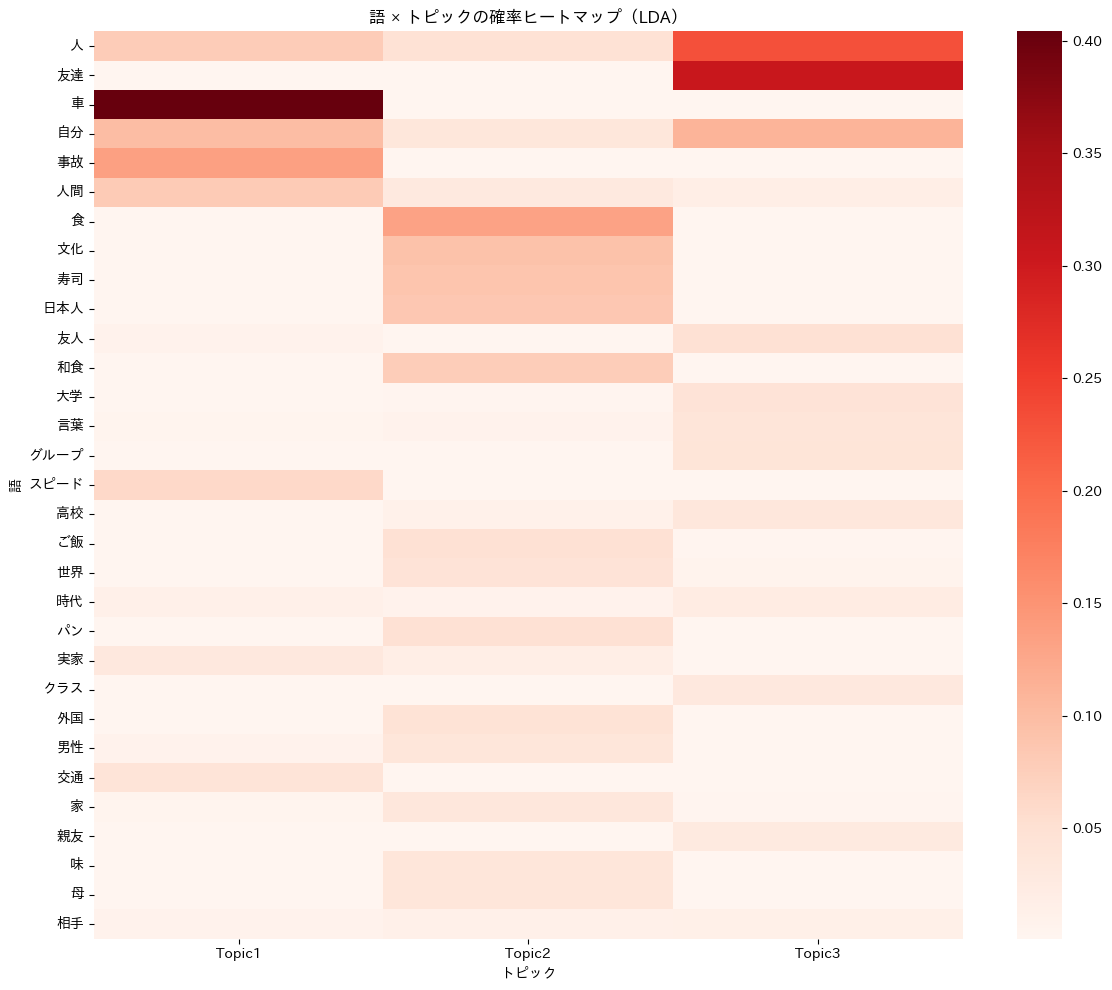

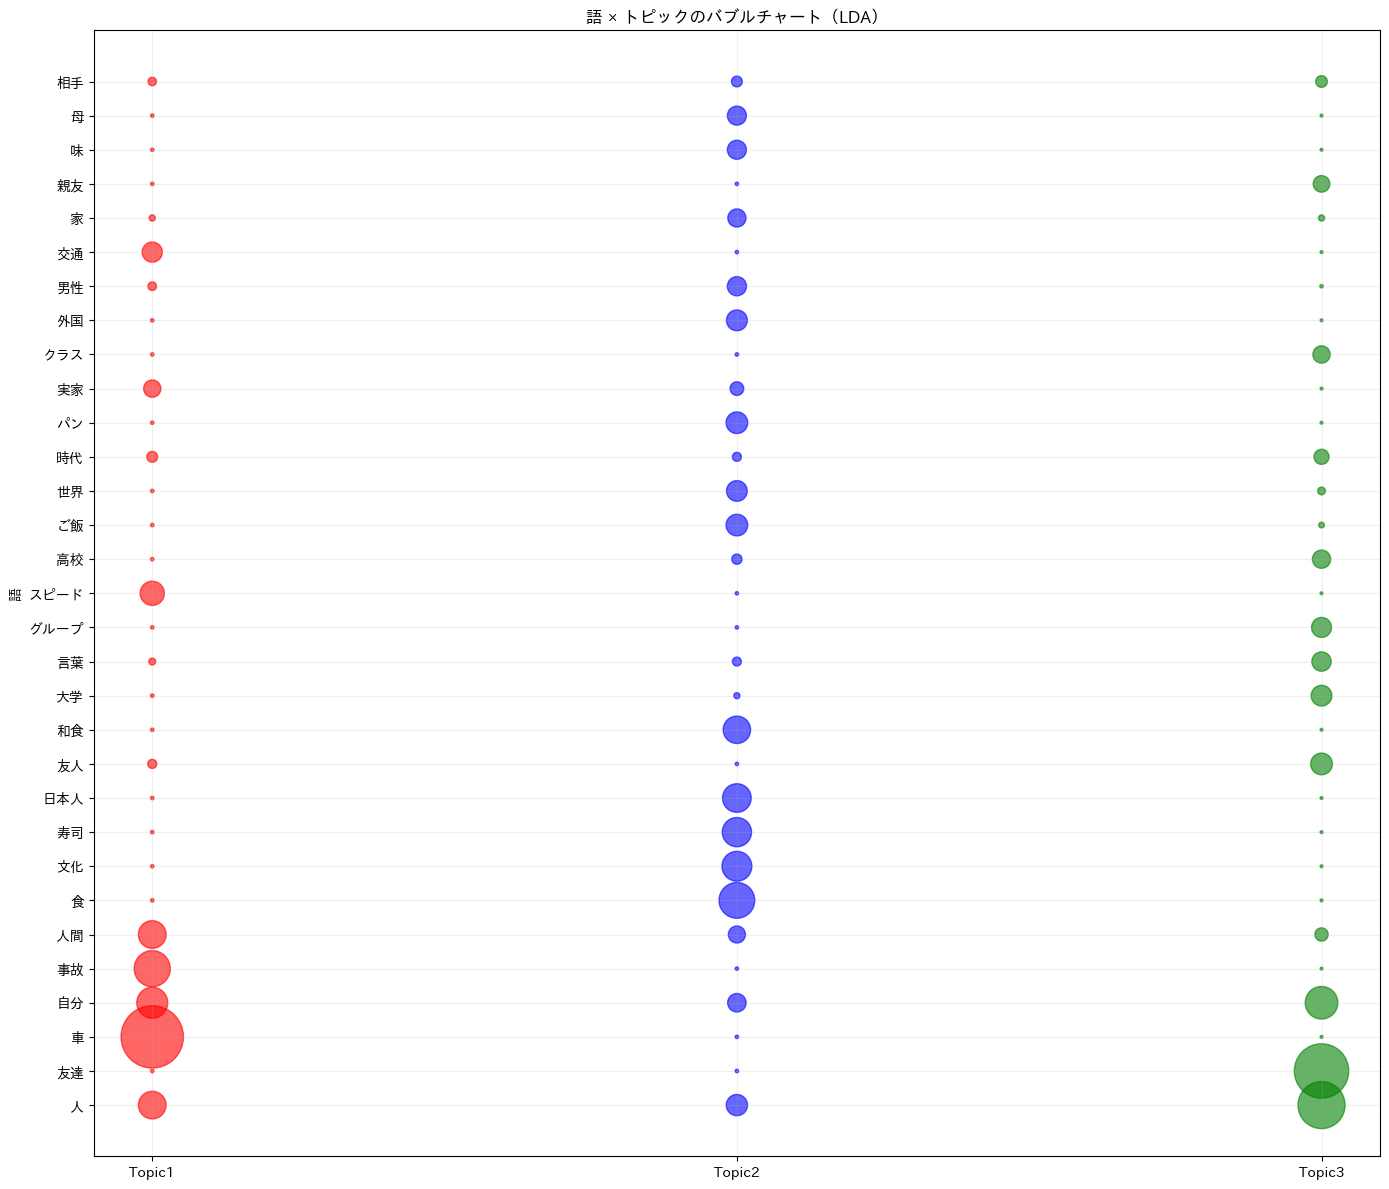

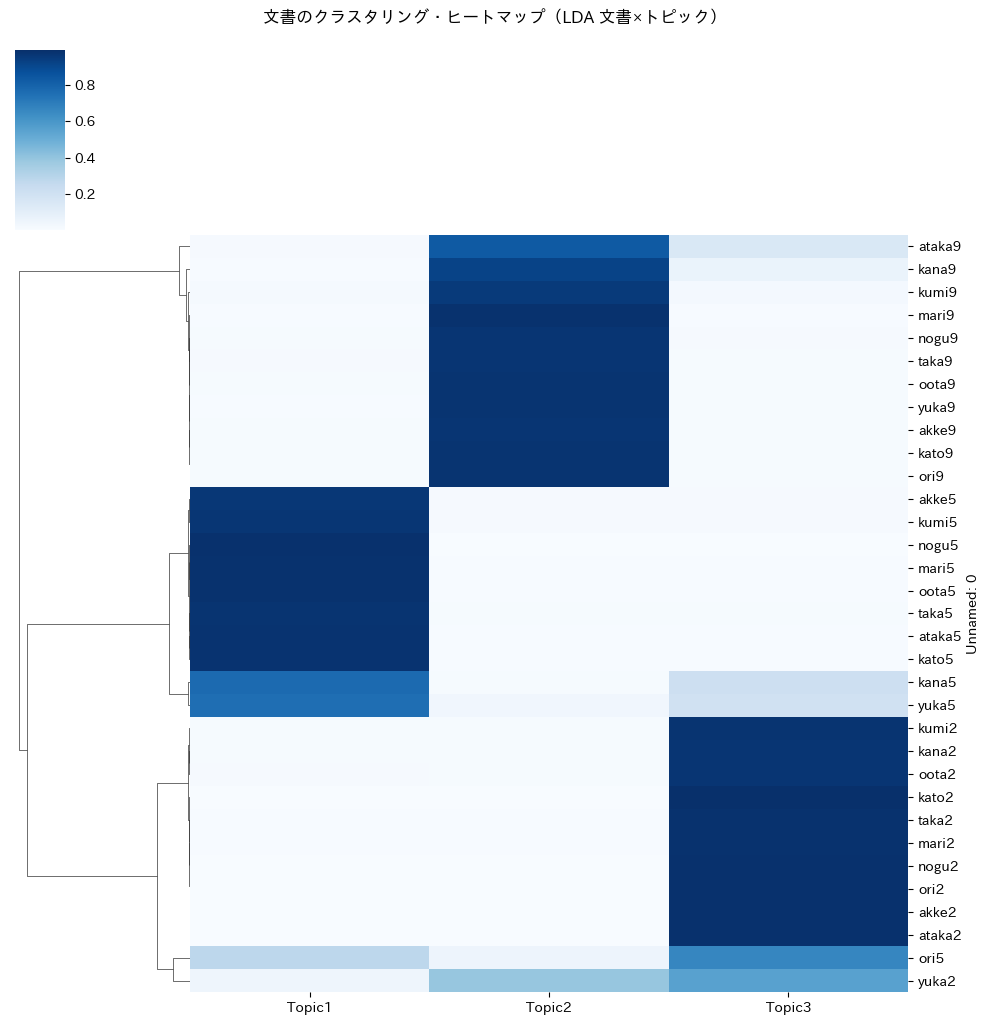

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation

# ============================================================
# 設定
# ============================================================
use_others = False
n_topics = 3      
random_state = 0

# ============================================================
# データ読み込み & 整形
# ============================================================
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding="shift-jis")

doc_labels = d1.iloc[:, 0]                 # 文書ラベル
X= d1.iloc[:, 1:]                      # 語データ（最後の列は文種）
X.index = doc_labels

if not use_others:
    X = X.drop(columns=["OTHERS"], errors="ignore")

# X = df.copy()

# ============================================================
# LDA 実行
# ============================================================
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=random_state,
    learning_method='batch'
)

lda.fit(X.values)

# 文書×トピック確率
doc_topic = lda.transform(X.values)
doc_topic_df = pd.DataFrame(doc_topic, index=X.index,
                            columns=[f"Topic{i+1}" for i in range(n_topics)])

# 語×トピック確率（語 × Topic に転置）
topic_word = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]
topic_word_df = pd.DataFrame(topic_word.T, 
                             index=X.columns,
                             columns=[f"Topic{i+1}" for i in range(n_topics)])

print("\n===== 語 × トピックの確率行列 =====")
print(topic_word_df.round(3))

# ============================================================
# ① 語 × トピックのヒートマップ
# ============================================================

plt.figure(figsize=(12, 10))
sns.heatmap(topic_word_df, cmap="Reds")
plt.title("語 × トピックの確率ヒートマップ（LDA）")
plt.xlabel("トピック")
plt.ylabel("語")
plt.tight_layout()
plt.show()

# ============================================================
# ② 語 × トピックのバブルチャート（トピックごとに色分け）
# ============================================================

# トピックごとの鮮やかな色
topic_colors = ["red", "blue", "green", "orange", "purple", "cyan"]

bubble_df = topic_word_df.reset_index().melt(
    id_vars="index",
    var_name="Topic",
    value_name="Prob"
)
bubble_df.columns = ["Word", "Topic", "Prob"]

plt.figure(figsize=(14, 12))

for i, topic in enumerate(topic_word_df.columns):
    sub = bubble_df[bubble_df["Topic"] == topic]
    plt.scatter(
        x=[topic]*len(sub),
        y=sub["Word"],
        s=sub["Prob"] * 5000,     # バブルサイズ
        alpha=0.6,
        color=topic_colors[i]
    )

plt.ylabel("語")
plt.title("語 × トピックのバブルチャート（LDA）")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# ③ 文書 × トピックのクラスタリングヒートマップ（削除しない）
# ============================================================

g = sns.clustermap(
    doc_topic_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    figsize=(10, 10),
    row_cluster=True,
    col_cluster=False
)

# 行ラベルを横書きにする
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

plt.suptitle("文書のクラスタリング・ヒートマップ（LDA 文書×トピック）", y=1.02)
plt.show()
